In [1]:
import sys
sys.path.append("../src")

import numpy as np
from reinforcement import EpsilonGreedyBandit, simulate_feedback_loop

np.random.seed(42)
n_items = 10
true_prefs = np.random.beta(2, 5, n_items)

print("True (hidden) preference probabilities per item:")
print(true_prefs)

bandit = EpsilonGreedyBandit(n_arms=n_items, epsilon=0.1)
history = simulate_feedback_loop(bandit, true_prefs, rounds=1000)

print("\nLearned values per item after 1000 rounds:")
print(bandit.values)

True (hidden) preference probabilities per item:
[0.35367666 0.24855807 0.41595909 0.15996758 0.55028308 0.11094529
 0.50989664 0.17727038 0.19829047 0.37623679]

Learned values per item after 1000 rounds:
[0.40384615 0.2        0.28571429 0.         0.56219512 0.
 0.25       0.25       0.16666667 0.41666667]


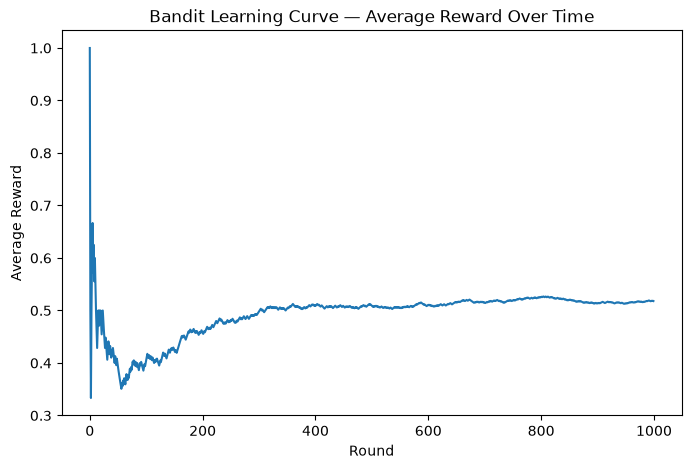

In [2]:
import matplotlib.pyplot as plt

rewards = [r for _, r in history]
cumulative_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_avg)
plt.title("Bandit Learning Curve — Average Reward Over Time")
plt.xlabel("Round")
plt.ylabel("Average Reward")
plt.savefig("../outputs/bandit_learning_curve.png")
plt.show()

In [3]:
best_arm = np.argmax(true_prefs)
chosen_arms = [a for a, _ in history]
best_arm_pct = chosen_arms.count(best_arm) / len(chosen_arms) * 100

print(f"Best arm (item index): {best_arm}, true preference: {true_prefs[best_arm]:.3f}")
print(f"Bandit chose the best arm in {best_arm_pct:.1f}% of rounds")

Best arm (item index): 4, true preference: 0.550
Bandit chose the best arm in 82.0% of rounds


## Reinforcement Learning Summary

An epsilon-greedy multi-armed bandit (epsilon=0.1) was used to simulate adaptive
recommendation refinement. Given 10 candidate items with hidden true preference
probabilities, the bandit learned to identify the best-performing item (true
preference: 0.550) purely through trial-and-error feedback, converging to an
estimated value of ~0.56 after 1000 rounds and selecting the optimal item in
82% of rounds — consistent with the theoretical ceiling given 10% forced exploration.

**How this connects to the recommender system:** rather than always showing a
static Top-N list from the SVD model, the system could treat each candidate
recommendation as a bandit arm, using real user clicks/ignores as reward signals
to continuously re-rank which items get surfaced — allowing the system to adapt
to preference drift over time without retraining the full model.